# Baseline: EFMRec

### Estudiantes

*   Alonso Casanova
*   Bruno Cerda
*   Berioska Contreras 

## Parte 0: Liberias

In [1]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import glob
import gdown
import zipfile
import torch
import torch.nn as nn
from transformers import CLIPProcessor, CLIPModel
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import numpy as np
import scipy.sparse as sp
import torch.optim as optim
import random
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import copy
import gc


device = "cuda" if torch.cuda.is_available() else "cpu"

/home/brubuntu/Desktop/PUC/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parte 1: Datos

### 1.1 Descargar

In [2]:
# Esta celda descarga todos los datos, y los extrae

url = 'https://drive.google.com/drive/folders/1MvRYh3SudRabydH2eAAzRq2K5Os1j41-'
output_folder = 'recsys-pf'

gdown.download_folder(url, output=output_folder, quiet=False, use_cookies=False)
zip_search_pattern = os.path.join(output_folder, '*.zip')
zip_files = glob.glob(zip_search_pattern)
image_zip_path = zip_files[0]

with zipfile.ZipFile(image_zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_folder)

Retrieving folder contents


Processing file 1_CZsjxiXc-LsiXjRpiuEsGCZdvq7i0au interaction.csv
Processing file 1R95OpzeRwkG0Ljc9MJqKJI3zMSwqItHV item_info.csv
Processing file 1P4kKxL5xgJ_ePj955gIEej78bsnk36M5 resized_images.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1_CZsjxiXc-LsiXjRpiuEsGCZdvq7i0au
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/interaction.csv
100%|██████████████████████████████████████| 28.1M/28.1M [00:02<00:00, 11.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1R95OpzeRwkG0Ljc9MJqKJI3zMSwqItHV
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/item_info.csv
100%|██████████████████████████████████████| 25.0M/25.0M [00:02<00:00, 11.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5
From (redirected): https://drive.google.com/uc?id=1P4kKxL5xgJ_ePj955gIEej78bsnk36M5&confirm=t&uuid=2d3aa5ce-4b51-4b17-b3ee-1a1af993e1a2
To: /home/brubuntu/Desktop/PUC/recsys/recsys-pf/notebooks/recsys-pf/resized_images.zip
100%|████████████████████████████████████████| 163M/163M [00:14<00:00, 11.5

In [3]:
interaction_df = pd.read_csv('recsys-pf/interaction.csv')
item_info_df = pd.read_csv('recsys-pf/item_info.csv')
item_info_df = item_info_df.dropna()

### 1.2 Preprocesar (Subsamplear)

In [4]:
n_items_to_sample = 15000
sampled_item_info_df = item_info_df.sample(n=n_items_to_sample, random_state=5)

valid_item_ids = sampled_item_info_df['item_id'].unique()

sampled_interaction_df = interaction_df[interaction_df['item_id'].isin(valid_item_ids)]

image_folder = 'recsys-pf/resized_images'
valid_image_paths = [os.path.join(image_folder, f"{item_id}.jpg") for item_id in valid_item_ids]

print(f"Sampled items: {len(sampled_item_info_df)}")
print(f"Sampled interactions: {len(sampled_interaction_df)}")
print(f"Number of valid image paths: {len(valid_image_paths)}")

Sampled items: 15000
Sampled interactions: 188108
Number of valid image paths: 15000


## Parte 2: Feature Extraction (Images + Text -> Clip encoder -> features)

1. **Preparación del Dataset**: Estructura la clase `ExtractionDataset` para cargar las imágenes desde el disco y concatenar el texto disponible (etiquetas, título y descripción) de cada ítem evitando valores nulos.

2. **Configuración de CLIP y DataLoader**: Configura el procesador y el modelo CLIP de Hugging Face en modo de evaluación, congela los gradientes de PyTorch y envuelve el dataset en un `DataLoader` optimizado con procesamiento en paralelo mediante hilos.

3. **Procesamiento de Imágenes y Texto**: Itera sobre los lotes decodificando y transformando las imágenes y los textos en tensors para pasarlos por las redes de CLIP, obteniendo las representaciones vectoriales en la GPU.

4. **Normalización L2**: Divide los vectores resultantes por su norma Euclidiana para proyectar las características visuales y textuales en un espacio común donde se puedan comparar directamente mediante la similitud de coseno.

5. **Transferencia a CPU y Almacenamiento**: Mueve los vectores finales mapeados por ítem de vuelta a la memoria del sistema (CPU) para no saturar la GPU y los guarda en un archivo binario `.pt`.

In [5]:
class ExtractionDataset(Dataset):
    def __init__(self, valid_item_ids, item_info_df, image_folder):
        self.valid_item_ids = valid_item_ids
        self.image_folder = image_folder
        self.item_info_df = item_info_df.set_index('item_id')

    def __len__(self):
        return len(self.valid_item_ids)

    def __getitem__(self, idx):
        item_id = self.valid_item_ids[idx]
        
        image_path = os.path.join(self.image_folder, f"{item_id}.jpg")
        image = Image.open(image_path).convert("RGB")
        row = self.item_info_df.loc[item_id]
        
        tag = str(row.get('tag', ''))
        title = str(row.get('title', ''))
        desc = str(row.get('description', ''))
        
        parts = [p for p in [tag, title, desc] if p and p.lower() != 'nan']
        final_text = " ".join(parts)

        return {
            "item_id": item_id,
            "image": image,
            "text": final_text
        }

def extraction_collate_fn(batch):
    return {
        "item_ids": [item["item_id"] for item in batch],
        "images": [item["image"] for item in batch],
        "texts": [item["text"] for item in batch]
    }

In [6]:
model_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(model_id)
clip_model = CLIPModel.from_pretrained(model_id).to(device)
clip_model.eval()
torch.set_grad_enabled(False)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [7]:
extraction_dataset = ExtractionDataset(valid_item_ids, sampled_item_info_df, image_folder)
dataloader = DataLoader(
    extraction_dataset, 
    batch_size=32, 
    shuffle=False, 
    collate_fn=extraction_collate_fn,
    num_workers=4,
    pin_memory=True
)

In [8]:
image_embeddings = {}
text_embeddings = {}

for batch in tqdm(dataloader, desc="Extracting CLIP Features"):
    item_ids = batch["item_ids"]
    images = batch["images"]
    texts = batch["texts"]

    img_inputs = clip_processor(images=images, return_tensors="pt").to(device)
    img_feats = clip_model.get_image_features(**img_inputs)
    img_feats = img_feats / img_feats.norm(p=2, dim=-1, keepdim=True)

    txt_inputs = clip_processor(text=texts, return_tensors="pt", padding=True, truncation=True).to(device)
    txt_feats = clip_model.get_text_features(**txt_inputs)
    txt_feats = txt_feats / txt_feats.norm(p=2, dim=-1, keepdim=True)

    for i_id, i_feat, t_feat in zip(item_ids, img_feats, txt_feats):
        image_embeddings[i_id] = i_feat.cpu()
        text_embeddings[i_id] = t_feat.cpu()

Extracting CLIP Features: 100%|███████████████| 469/469 [00:26<00:00, 17.41it/s]


In [9]:
output_filepath = "pixelrec_clip_embeddings.pt"
print(f"\nSaving embeddings to {output_filepath}...")

torch.save({
    "image_embeddings": image_embeddings,
    "text_embeddings": text_embeddings
}, output_filepath)


Saving embeddings to pixelrec_clip_embeddings.pt...


## Parte 3: Early Fusion (Linear projection)

1. **Multimodal Fusion**: Combina los vectores de imagen y texto promediándolos si ambos existen, prioriza el disponible si falta uno, o genera un vector de ceros en su defecto.

2. **Inicialización y Proyección**: El modelo EFMRec inicializa tablas de embeddings tradicionales (CF) y proyecta las características multimodales fusionadas a una dimensión común.

3. **Propagación en Grafo (GCN)**: Ejecuta una función que concatena las representaciones y multiplica recursivamente la matriz de adyacencia para propagar información estructural a través de las capas del grafo.

4. **Extracción y Combinación**: Separa los resultados agregados del grafo de vuelta en usuarios e ítems para ambas ramas (CF y multimodal), y luego suma las salidas dándole un peso proporcional controlado por alfa.

5. **Indexación Final**: Filtra y extrae los embeddings finales calculados específicamente para los usuarios, ítems positivos e ítems negativos solicitados en el lote actual de entrenamiento.

In [5]:
saved_data = torch.load("pixelrec_clip_embeddings.pt")
image_embeddings = saved_data["image_embeddings"]
text_embeddings = saved_data["text_embeddings"]

In [6]:
image_embeddings['i103685'].shape

torch.Size([512])

In [7]:
text_embeddings['i103685'].shape

torch.Size([512])

In [8]:
fused_embeddings = {}

all_item_ids = list(image_embeddings.keys())
for item_id in all_item_ids:
    img_vec = image_embeddings.get(item_id)
    txt_vec = text_embeddings.get(item_id)
    
    img_present = img_vec is not None
    txt_present = txt_vec is not None
    
    if img_present and txt_present:
        fused_embeddings[item_id] = (img_vec + txt_vec) / 2
    elif img_present:
        fused_embeddings[item_id] = img_vec
    elif txt_present:
        fused_embeddings[item_id] = txt_vec
    else:
        fused_embeddings[item_id] = torch.zeros(512)

In [9]:
class EFMRec(nn.Module):
    def __init__(self, num_users, num_items, clip_dim=512, embed_dim=64, num_layers=3, alpha=0.1):
        super(EFMRec, self).__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.embed_dim = embed_dim
        self.num_layers = num_layers
        self.alpha = alpha

        self.mm_projection = nn.Linear(clip_dim, embed_dim)
        self.cf_user_embedding = nn.Embedding(num_users, embed_dim)
        self.cf_item_embedding = nn.Embedding(num_items, embed_dim)
        
        nn.init.xavier_uniform_(self.cf_user_embedding.weight)
        nn.init.xavier_uniform_(self.cf_item_embedding.weight)
        nn.init.xavier_uniform_(self.mm_projection.weight)

    def propagate_gcn(self, adj_matrix, user_emb, item_emb):
        all_emb = torch.cat([user_emb, item_emb], dim=0)
        embs = [all_emb]
        
        for _ in range(self.num_layers):
            all_emb = torch.sparse.mm(adj_matrix, embs[-1])
            embs.append(all_emb)
            
        return torch.stack(embs).mean(dim=0)

    def forward(self, adj_matrix, fused_features, user_indices, item_pos_indices, item_neg_indices):
        item_mm_init = self.mm_projection(fused_features)
        user_mm_init = torch.zeros(self.num_users, self.embed_dim, device=fused_features.device)
        
        all_mm = self.propagate_gcn(adj_matrix, user_mm_init, item_mm_init)
        user_mm_final, item_mm_final = torch.split(all_mm, [self.num_users, self.num_items])
        
        all_cf = self.propagate_gcn(adj_matrix, self.cf_user_embedding.weight, self.cf_item_embedding.weight)
        user_cf_final, item_cf_final = torch.split(all_cf, [self.num_users, self.num_items])
        
        user_final = user_cf_final + self.alpha * user_mm_final
        item_final = item_cf_final + self.alpha * item_mm_final

        u_emb = user_final[user_indices]
        i_pos_emb = item_final[item_pos_indices]
        i_neg_emb = item_final[item_neg_indices]

        return u_emb, i_pos_emb, i_neg_emb

## Parte 4: Matriz Adyacencia (LigthGCN)

1. **Codificación de Índices**: Transforma los identificadores originales de usuarios e ítems en categorías numéricas secuenciales continuas (de 0 a N-1) usando códigos de categorías de Pandas.


2. **Construcción Simétrica**: Duplica los enlaces mapeando tanto conexiones de usuario a ítem como de ítem a usuario para estructurar una matriz de adyacencia dispersa y bidireccional de tamaño combinada.


3. **Cálculo de Grados**: Suma las interacciones por fila para obtener el grado de cada nodo y calcula su raíz cuadrada inversa para manejar la normalización de la estructura del grafo.


4. **Normalización Simétrica**: Multiplica la matriz de adyacencia original por la matriz diagonal de grados inversa en ambos lados para equilibrar el peso de los nodos con excesivas conexiones.


5. **Conversión a Tensor Sparse**: Convierte el resultado final normalizado de Scipy a un tensor sparse de PyTorch optimizado, combinando duplicados y enviándolo directamente a la GPU para el entrenamiento.

In [10]:
def build_adj_matrix(interaction_df, num_users, num_items):
    user_indices = interaction_df['user_id'].values
    item_indices = interaction_df['item_id'].values + num_users
    
    rows = np.concatenate([user_indices, item_indices])
    cols = np.concatenate([item_indices, user_indices])
    vals = np.ones(len(rows))
    
    adj = sp.coo_matrix((vals, (rows, cols)), shape=(num_users + num_items, num_users + num_items))

    rowsum = np.array(adj.sum(1))
    d_inv = np.power(rowsum, -0.5).flatten()
    d_inv[np.isinf(d_inv)] = 0.
    d_mat_inv = sp.diags(d_inv)
    
    norm_adj = d_mat_inv.dot(adj).dot(d_mat_inv)
    
    coo = norm_adj.tocoo()
    indices = torch.LongTensor(np.vstack([coo.row, coo.col]))
    values = torch.FloatTensor(coo.data)
    
    return torch.sparse_coo_tensor(indices, values, size=coo.shape).coalesce().to(device)

sampled_interaction_df.loc[:, 'user_id'] = sampled_interaction_df['user_id'].astype('category').cat.codes
sampled_interaction_df.loc[:, 'item_id'] = sampled_interaction_df['item_id'].astype('category').cat.codes

num_users = sampled_interaction_df['user_id'].nunique()
num_items = sampled_interaction_df['item_id'].nunique()

adj_matrix = build_adj_matrix(sampled_interaction_df, num_users, num_items)

/tmp/ipykernel_7983/4128894011.py:22: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(indices, values, size=coo.shape).coalesce().to(device)


## Parte 5: Training loop (BPR & Contrastive loss)

1. **Muestreo de triples**: Extrae un conjunto aleatorio de interacciones positivas y busca, para cada usuario, un ítem negativo con el que nunca haya interactuado para construir las tripletas de entrenamiento.


2. **Cálculo de Pérdidas Completo**: Evalúa la pérdida BPR para optimizar el ordenamiento, añade regularización L2 para prevenir overfitting y aplica una pérdida contrastiva (InfoNCE) sobre la rama colaborativa del modelo.


3. **Inicialización del Entorno**: Divide los datos asegurando tipos enteros para PyTorch, activa el cálculo de gradientes a nivel global, instancia el modelo EFMRec con sus hiperparámetros y configura el optimizador Adam.


4. **Ciclo de Optimización**: Itera a través de las epochs ejecutando el forward pass, calculando los errores combinados, realizando backprop y actualizando los pesos del modelo.


5. **Validación y Early Stopping**: Evalúa el modelo cada 50 epochs en modo sin gradientes con los datos reservados y detiene el entrenamiento de manera anticipada si la pérdida de validación deja de mejorar durante un número determinado de ciclos.

In [11]:
def sample_triplets(interaction_df):
    pos_sample = interaction_df.sample(n=1024)
    users = torch.LongTensor(pos_sample['user_id'].values).to(device)
    pos_items = torch.LongTensor(pos_sample['item_id'].values).to(device)
    
    neg_items = []
    all_items = set(range(num_items))
    for u in pos_sample['user_id']:
        user_items = set(interaction_df[interaction_df['user_id'] == u]['item_id'])
        neg_item = random.choice(list(all_items - user_items))
        neg_items.append(neg_item)
        
    neg_items = torch.LongTensor(neg_items).to(device)
    return users, pos_items, neg_items


def compute_val_loss(model, adj_matrix, val_dataframe, features):
    users, pos_items, neg_items = sample_triplets(val_dataframe)
    
    u_emb, i_pos_emb, i_neg_emb = model(adj_matrix, features, users, pos_items, neg_items)
    
    y_ui = (u_emb * i_pos_emb).sum(dim=1)
    y_uj = (u_emb * i_neg_emb).sum(dim=1)
    
    return bpr_loss(y_ui, y_uj).item()


def bpr_loss(y_ui, y_uj):
    return -torch.mean(F.logsigmoid(y_ui - y_uj))


def contrastive_loss(cf_embs):
    return F.cross_entropy(torch.mm(cf_embs, cf_embs.t()), torch.arange(cf_embs.size(0)).to(device))

In [12]:
def evaluate_scores(all_scores, test_df, train_df, num_users, k_list=[5, 10]):
    test_users = test_df['user_id'].unique()
    
    train_interactions = train_df.groupby('user_id')['item_id'].apply(set).to_dict()
    test_interactions = test_df.groupby('user_id')['item_id'].apply(set).to_dict()
    
    metrics = {'Recall@5': [], 'NDCG@5': [], 'MAP@5': [], 'Recall@10': [], 'NDCG@10': [], 'MAP@10': []}
    
    for u in test_users:
        if u not in test_interactions:
            continue
            
        true_items = list(test_interactions[u])
        
        if u in train_interactions:
            train_items = list(train_interactions[u])
            all_scores[u, train_items] = -float('inf')
            
        user_scores = all_scores[u]
        _, top_indices = torch.topk(user_scores, max(k_list))
        top_indices = top_indices.cpu().numpy()
        
        for k in k_list:
            top_k_indices = top_indices[:k]
            hits = np.isin(top_k_indices, true_items)
            
            recall = np.sum(hits) / len(true_items)
            metrics[f'Recall@{k}'].append(recall)
            
            dcg = 0.0
            idcg = 0.0
            ap = 0.0
            hits_so_far = 0
            
            for i in range(len(true_items)):
                if i < k:
                    idcg += 1.0 / np.log2(i + 2)
            
            for i, hit in enumerate(hits):
                if hit:
                    dcg += 1.0 / np.log2(i + 2)
                    hits_so_far += 1
                    ap += hits_so_far / (i + 1)
                    
            ndcg = dcg / idcg if idcg > 0 else 0.0
            metrics[f'NDCG@{k}'].append(ndcg)
            
            ap = ap / min(len(true_items), k)
            metrics[f'MAP@{k}'].append(ap)
            
    results = {}
    for key, val_list in metrics.items():
        results[key] = np.mean(val_list)
        
    return results

In [13]:
sampled_interaction_df = sampled_interaction_df.sort_values('timestamp')
total_rows = len(sampled_interaction_df)
train_split_idx = int(total_rows * 0.80)
val_split_idx = int(total_rows * 0.90)
train_df = sampled_interaction_df.iloc[:train_split_idx].copy()
val_df = sampled_interaction_df.iloc[train_split_idx:val_split_idx].copy()
test_df = sampled_interaction_df.iloc[val_split_idx:].copy()

train_df['user_id'] = train_df['user_id'].astype(int)
train_df['item_id'] = train_df['item_id'].astype(int)
val_df['user_id'] = val_df['user_id'].astype(int)
val_df['item_id'] = val_df['item_id'].astype(int)
test_df['user_id'] = test_df['user_id'].astype(int)
test_df['item_id'] = test_df['item_id'].astype(int)

train_adj_matrix = build_adj_matrix(train_df, num_users, num_items)

ordered_original_ids = [str(iid) for iid in valid_item_ids]
fused_features = torch.stack([fused_embeddings[iid] for iid in ordered_original_ids]).to(device)

torch.set_grad_enabled(True)

lr = 1e-3
lambda_reg = 1e-4
lambda_cl = 0.1

model = EFMRec(
    num_users=num_users, 
    num_items=num_items, 
    clip_dim=512, 
    embed_dim=64, 
    num_layers=3, 
    alpha=0.1
).to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)

train_loss_history = []
val_recall_history = []
val_ndcg_history = []
val_map_history = []
val_epochs = []

max_epochs = 5000
best_val_mean = -float('inf')
best_model_state = None

epoch_bar = tqdm(range(max_epochs), desc="Training Model")

for epoch in epoch_bar:
    model.train()
    optimizer.zero_grad()
    
    users, pos_items, neg_items = sample_triplets(train_df)
    
    u_emb, i_pos_emb, i_neg_emb = model(train_adj_matrix, fused_features, users, pos_items, neg_items)
    
    y_ui = (u_emb * i_pos_emb).sum(dim=1)
    y_uj = (u_emb * i_neg_emb).sum(dim=1)
    
    loss_bpr = bpr_loss(y_ui, y_uj)
    loss_reg = lambda_reg * (u_emb.norm(2) + i_pos_emb.norm(2) + i_neg_emb.norm(2))
    loss_cl = lambda_cl * contrastive_loss(torch.cat([u_emb, i_pos_emb]))
    
    loss = loss_bpr + loss_reg + loss_cl
    
    loss.backward()
    optimizer.step()
    
    train_loss_history.append(loss.item())
    epoch_bar.set_postfix(loss=loss.item())

    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            all_users = torch.arange(num_users).to(device)
            all_items = torch.arange(num_items).to(device)
            
            u_emb_val, i_pos_emb_val, _ = model(train_adj_matrix, fused_features, all_users, all_items, all_items)
            
            u_emb_cpu = u_emb_val.cpu()
            i_pos_emb_cpu = i_pos_emb_val.cpu()
            
            del u_emb_val
            del i_pos_emb_val
            torch.cuda.empty_cache()
            gc.collect()
            
            val_scores = torch.matmul(u_emb_cpu, i_pos_emb_cpu.t())
            
            val_metrics = evaluate_scores(val_scores, val_df, train_df, num_users)
            
            current_recall = val_metrics['Recall@10']
            current_ndcg = val_metrics['NDCG@10']
            current_map = val_metrics['MAP@10']
            
            current_mean = (current_recall + current_ndcg + current_map) / 3.0
            
            val_recall_history.append(current_recall)
            val_ndcg_history.append(current_ndcg)
            val_map_history.append(current_map)
            val_epochs.append(epoch)
            
            del val_scores
            gc.collect()
            
            if current_mean > best_val_mean:
                best_val_mean = current_mean
                best_model_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_model_state)

/tmp/ipykernel_7983/4128894011.py:12: RuntimeWarning: divide by zero encountered in power
  d_inv = np.power(rowsum, -0.5).flatten()
Training Model: 100%|████████████| 5000/5000 [35:48<00:00,  2.33it/s, loss=0.23]


<All keys matched successfully>

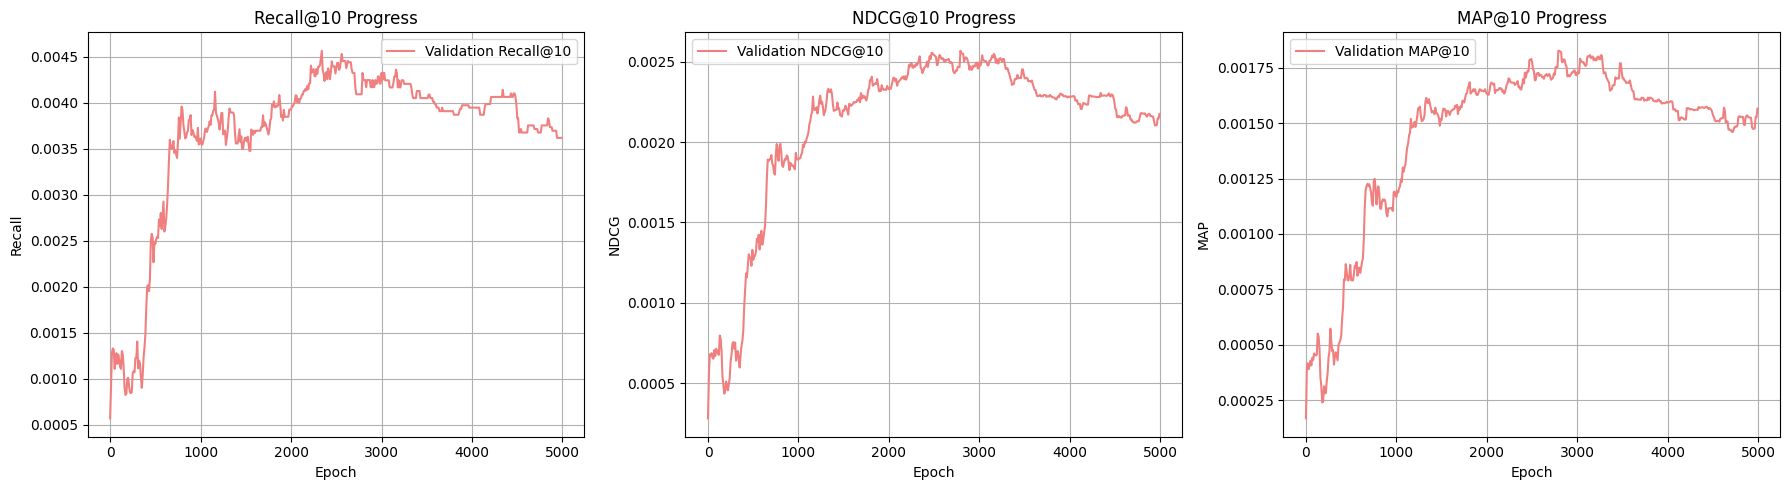

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(val_epochs, val_recall_history, label="Validation Recall@10", color="lightcoral")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Recall")
axes[0].set_title("Recall@10 Progress")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_epochs, val_ndcg_history, label="Validation NDCG@10", color="lightcoral")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG")
axes[1].set_title("NDCG@10 Progress")
axes[1].legend()
axes[1].grid(True)

axes[2].plot(val_epochs, val_map_history, label="Validation MAP@10", color="lightcoral")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("MAP")
axes[2].set_title("MAP@10 Progress")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## Parte 6: Evaluation

1. **Predicciones**: Calcula las puntuaciones de afinidad multiplicando las representaciones latentes de todos los usuarios e ítems obtenidas del modelo entrenado y de los algoritmos de referencia.


2. **Masking**: Identifica los ítems con los que cada usuario ya interactuó en el conjunto de entrenamiento y penaliza sus puntuaciones asignándoles un valor de infinito negativo.


3. **Filtrado de Recomendaciones**: Extrae los índices de los mejores ítems recomendados utilizando operaciones de ordenamiento sobre las puntuaciones calculadas para evaluar ventanas de tamaño K=10 y K=20.


4. **Cálculo de Recall y NDCG**: Compara los elementos sugeridos contra las interacciones reales del conjunto de validación, midiendo tanto la cantidad de aciertos obtenidos como la calidad de su posición en la lista.


5. **Consolidación Comparativa**: Promedia las métricas individuales de todos los usuarios de prueba y construye un cuadro unificado que contrasta el desempeño de EFMRec frente a los tres modelos base.

In [15]:
model.eval()
with torch.no_grad():
    all_users = torch.arange(num_users).to(device)
    all_items = torch.arange(num_items).to(device)
    u_emb, i_pos_emb, _ = model(train_adj_matrix, fused_features, all_users, all_items, all_items)
    
    u_emb_cpu = u_emb.cpu()
    i_pos_emb_cpu = i_pos_emb.cpu()
    
    del u_emb
    del i_pos_emb
    torch.cuda.empty_cache()
    
    efmrec_scores = torch.matmul(u_emb_cpu, i_pos_emb_cpu.t())

eval_results = evaluate_scores(efmrec_scores, test_df, train_df, num_users)

del efmrec_scores
gc.collect()

baseline_results = []
baseline_results.append({'Model': 'EFMRec', **eval_results})

random_scores = torch.rand(num_users, num_items)
res_random = evaluate_scores(random_scores.clone(), test_df, train_df, num_users)

del random_scores
gc.collect()

baseline_results.append({'Model': 'Random', **res_random})

item_counts = train_df.groupby('item_id').size()
pop_scores = torch.zeros(num_items)
for idx, count in item_counts.items():
    pop_scores[idx] = count
popularity_scores = pop_scores.unsqueeze(0).repeat(num_users, 1)
res_pop = evaluate_scores(popularity_scores.clone(), test_df, train_df, num_users)

del popularity_scores
gc.collect()

baseline_results.append({'Model': 'Most Popular', **res_pop})

row = train_df['user_id'].values
col = train_df['item_id'].values
data = np.ones(len(row))
ui_matrix = sp.csr_matrix((data, (row, col)), shape=(num_users, num_items))
item_sim = cosine_similarity(ui_matrix.T, dense_output=False)
knn_scores_np = ui_matrix.dot(item_sim).toarray()
knn_scores = torch.FloatTensor(knn_scores_np)
res_knn = evaluate_scores(knn_scores.clone(), test_df, train_df, num_users)

del knn_scores
gc.collect()

baseline_results.append({'Model': 'Item-KNN', **res_knn})

comparison_df = pd.DataFrame(baseline_results)
display(comparison_df)

,Model,Recall@5,NDCG@5,MAP@5,Recall@10,NDCG@10,MAP@10
0,EFMRec,0.002196,0.001599,0.001249,0.003527,0.002064,0.001417
1,Random,0.000192,0.000146,0.000089,0.000430,0.000206,0.000105
2,Most Popular,0.000624,0.000583,0.000507,0.001033,0.000727,0.000558
3,Item-KNN,0.001414,0.000944,0.000748,0.001962,0.001144,0.000828
